In [14]:
import numpy as np
import pandas as pd
import sys
from sklearn.metrics import mean_squared_error
sys.path.append('../src')
from data_loader import DataLoader
from configs import MeasurementDataEnum, SetupEnum, ErrorEnum, Configs, NoiseTypeEnum, FilterEnum
from kalman_filters import CubatureKalmanFilter

%matplotlib inline
np.random.seed(777)

In this notebook, Cubature Kalman filter is introduced to the Kitti dataset. 
Cubature Kalman filter approximates posterior density by using sigma point methos simlar to the Unscented Kalman Filter.
In comparison to the other approximating method such as the Monte Carlo sampling methods, the sigma point approximation utilzes samll number of declarative points to grasp the posterior density. Thus, it is optimal approach.

- [Cubature Kalman filter description](#Cubature-Kalman-filter)
- [Load data](#Load-raw-data-0033)
- [Data visualization](#Display-data-with-noise)
- [Applying Cubature Kalman filter](#Applying-Unscented-Kalman-filter)
    - [Setup1](#Setup1-(IMU-input-->-CKF-with-Visual-Odometry-measurement))
        - [Setup1 result](#Setup1-Result)
    - [Setup2](#Setup2-(IMU-input-->-CKF-with-Visual-Odometry-and-GPS-measurement))
        - [Setup2 result](#Setup2-Result)
    - [Setup3](#Setup3-(INS-input-->-CKF-with-Visual-Odometry-and-INS-measurement))
        - [Setup3 result](#Setup3-Result)
- [Result](#Result)

# Cubature Kalman Filter

# Load raw data 0033

Data size: 1591
Shape:
GPS: (1591, 3)
VO: (1591, 3)
IMU: (1591, 6)
INS angle: (1591, 3)
INS velocity: (1591, 3)
Add noise to GPS data
Adding noise to VO data
Adding noise to IMU sensor data
Adding noise to linear acceleration
Adding noise to angular velocity
Adding noise to INS sensor data
Adding noise to linear velocity data
Data sampling is set to normal mode.


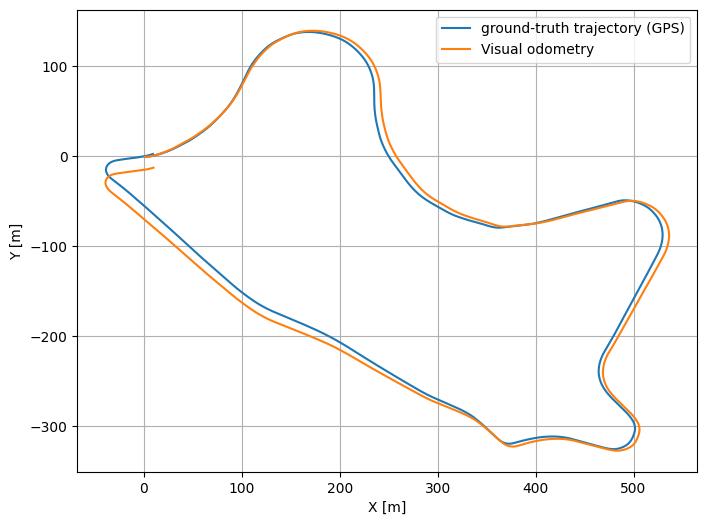

In [4]:
kitti_root_dir = '../data'
vo_root_dir = '../vo_estimates'
noise_vector_dir = '../exports/_noise_optimizations/noise_vectors'
kitti_date = '2011_09_30'
kitti_drive = '0033'

data = DataLoader(sequence_nr=kitti_drive, 
                  kitti_root_dir=kitti_root_dir, 
                  vo_root_dir=vo_root_dir,
                  noise_vector_dir=noise_vector_dir,
                  vo_dropout_ratio=0., 
                  gps_dropout_ratio=0.)

## Display data with noise

### VO trajectory with noise

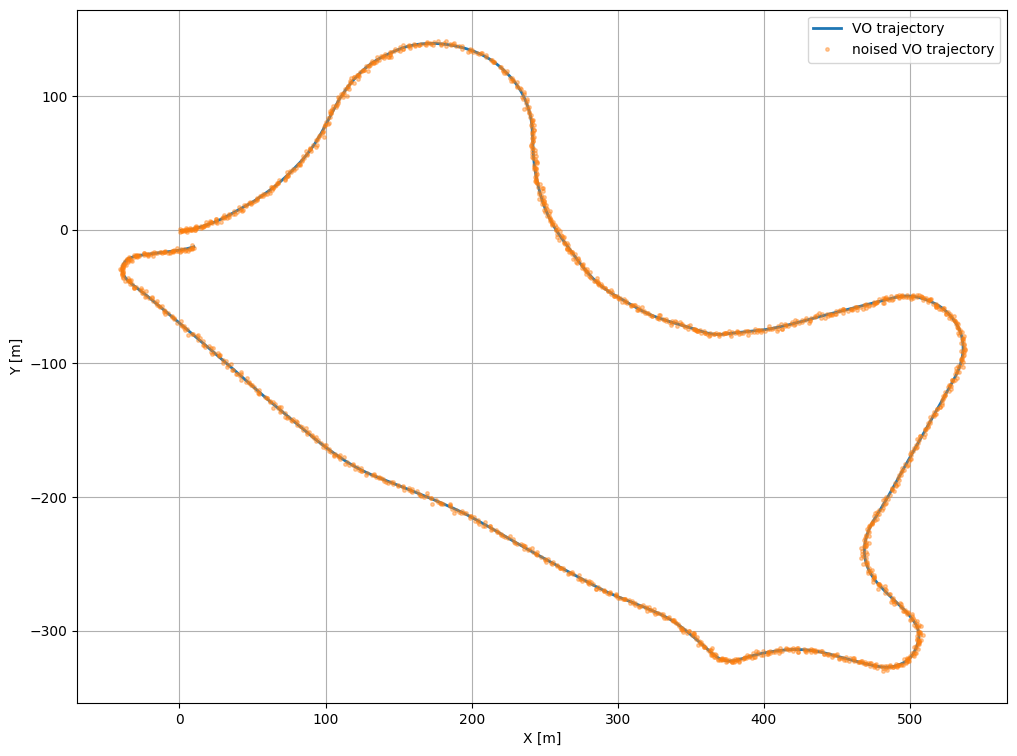

In [5]:
data.show_vo_with_noise()

### Linear acceleration with noise

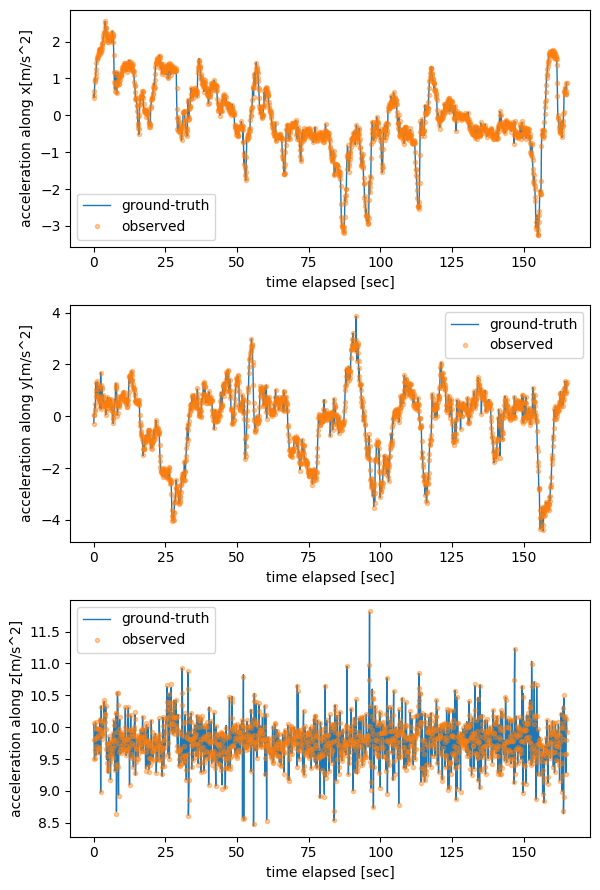

In [6]:
data.show_linear_acceleration_with_noise()

### Angular velocity with noise

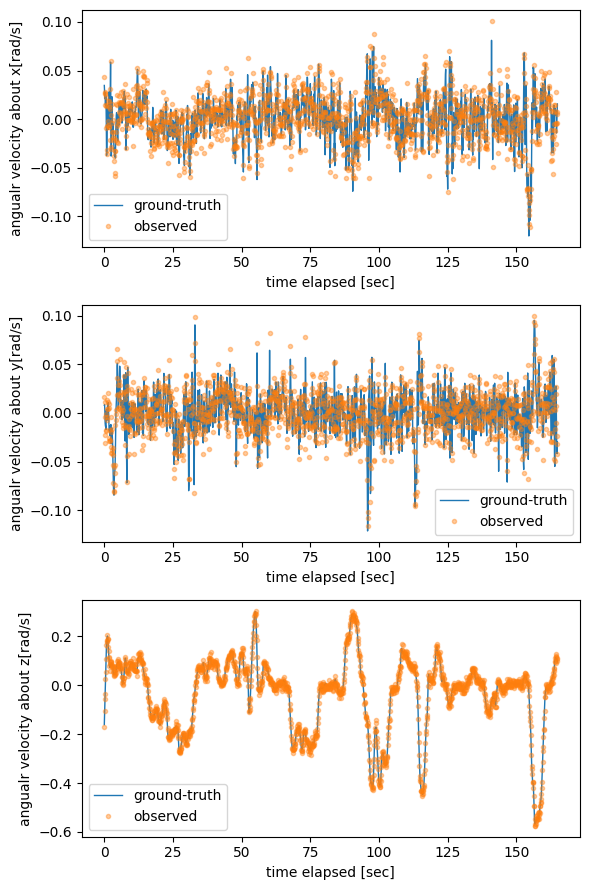

In [7]:
data.show_angular_velocity_with_noise()

### Linear velocity with noise

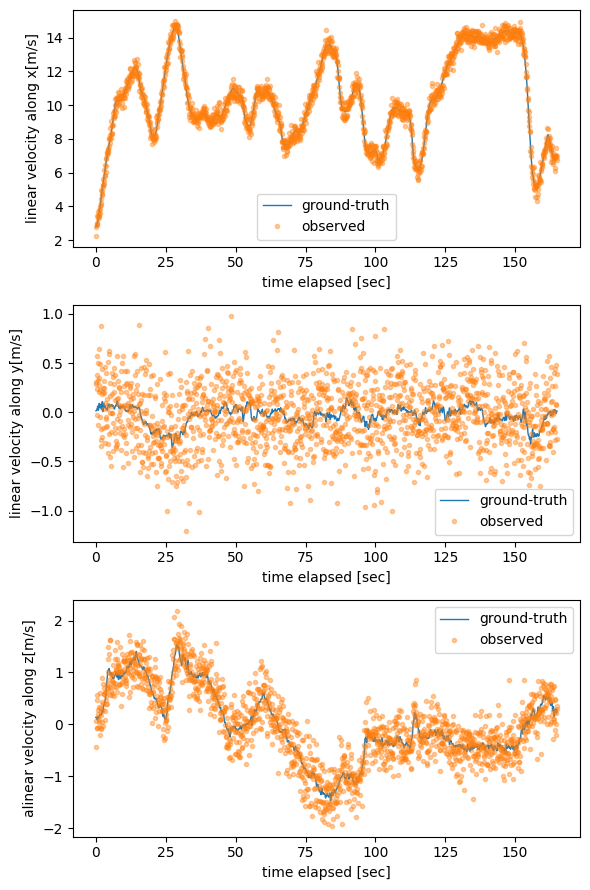

In [8]:
data.show_linear_velocity_with_noise()

# Applying Cubature Kalman Filter

In [18]:
mae_errors = []
rmse_errors = []
max_errors = []

mae_vo = np.absolute(np.subtract(data.GPS_measurements_in_meter.T[:2, :], 
                                 data.VO_measurements.T[:2, :]))
rmse_vo = np.sqrt(mean_squared_error(data.GPS_measurements_in_meter.T[:2, :], 
                                      data.VO_measurements.T[:2, :]))
max_vo = np.max(mae_vo)

print(f"MAE: {np.mean(mae_vo)}")
print(f"RMSE: {rmse_vo}")
print(f"MAX: {max_vo}")
mae_errors.append(np.round(np.mean(mae_vo), Configs.decimal_place))
rmse_errors.append(np.round(rmse_vo, Configs.decimal_place))
max_errors.append(np.round(max_vo, Configs.decimal_place))

MAE: 3.8204236798597773
RMSE: 5.448548458980544
MAX: 15.244254650508374


----

## Setup1 (IMU input -> EKF with Visual Odometry measurement)

In [10]:
x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(setup=SetupEnum.SETUP_1, filter_type=FilterEnum.CKF, noise_type=NoiseTypeEnum.CURRENT)

[CKF] start.


100%|█████████████████████████████████████| 1590/1590 [00:00<00:00, 2762.11it/s]


[CKF] errors: {<ErrorEnum.MAE: 1>: 3.909, <ErrorEnum.RMSE: 2>: 5.489, <ErrorEnum.MAX: 3>: 16.347}


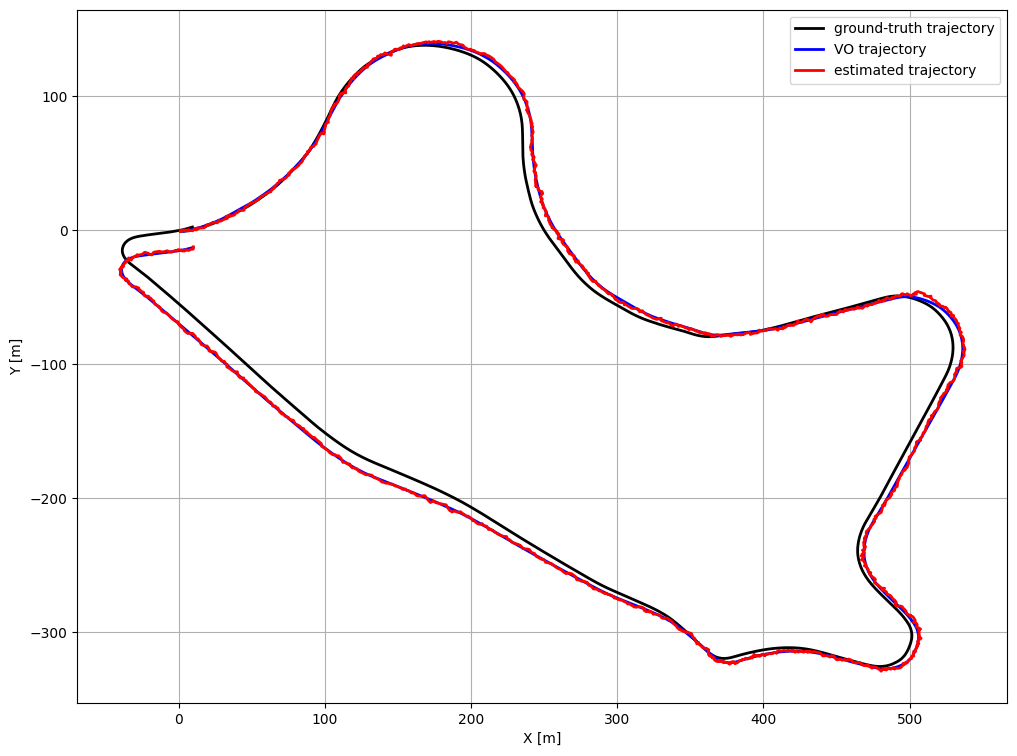

In [11]:
ckf1_0 = CubatureKalmanFilter(
    x=x_setup1.copy(), 
    P=P_setup1.copy(), 
    H=H_setup1.copy(),
    q=q1,
    r_vo=r_vo1,
    r_gps=r_gps1,
    setup=SetupEnum.SETUP_1,
)
error_ckf1_0 = ckf1_0.run(
    data=data,
    measurement_type=MeasurementDataEnum.ALL_DATA, 
    debug_mode=True,
    show_graph=True,
)

In [19]:
print(f"MAE: {error_ckf1_0[ErrorEnum.MAE]}")
print(f"RMSE: {error_ckf1_0[ErrorEnum.RMSE]}")
print(f"MAX: {error_ckf1_0[ErrorEnum.MAX]}")

mae_errors.append(error_ckf1_0[ErrorEnum.MAE])
rmse_errors.append(error_ckf1_0[ErrorEnum.RMSE])
max_errors.append(error_ckf1_0[ErrorEnum.MAX])

MAE: 3.909
RMSE: 5.489
MAX: 16.347


## Setup2 (IMU input -> UKF with Visual Odometry and GPS measurement)¶

In [20]:
x_setup2, P_setup2, H_setup2, q2, r_vo2, r_gps2 = data.get_initial_data(
  setup=SetupEnum.SETUP_2, 
  filter_type=FilterEnum.CKF, 
  noise_type=NoiseTypeEnum.CURRENT)

[CKF] start.


100%|█████████████████████████████████████| 1590/1590 [00:00<00:00, 2530.41it/s]


[CKF] errors: {<ErrorEnum.MAE: 1>: 1.536, <ErrorEnum.RMSE: 2>: 2.074, <ErrorEnum.MAX: 3>: 6.567}


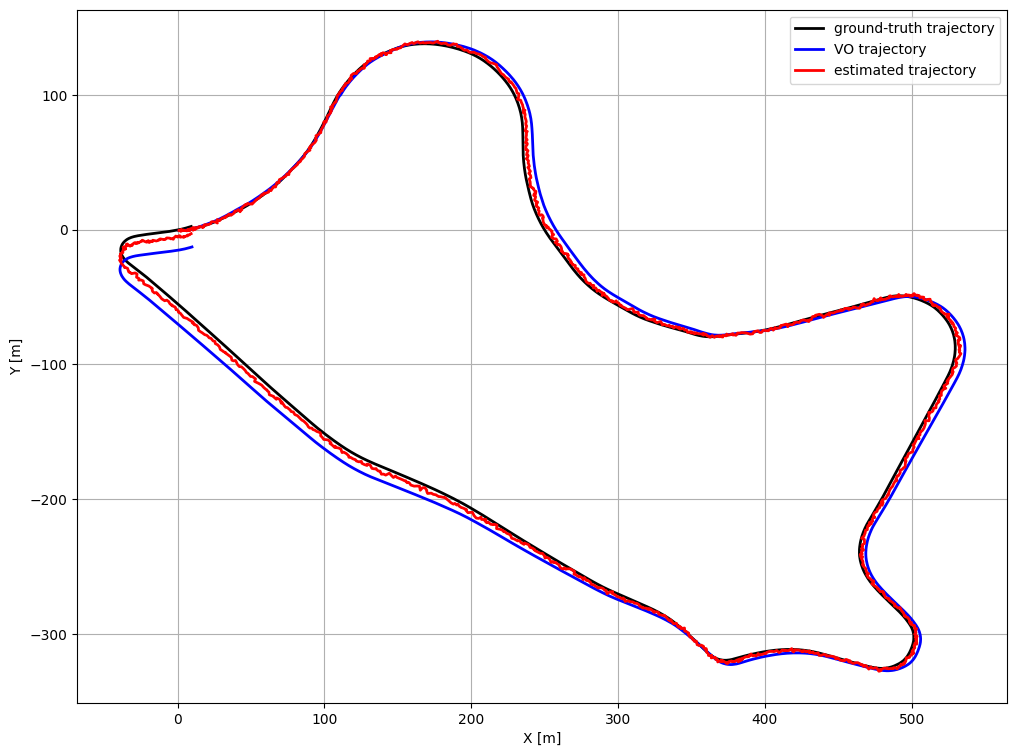

In [21]:
ckf2_0 = CubatureKalmanFilter(
    x=x_setup2.copy(), 
    P=P_setup2.copy(), 
    H=H_setup2.copy(),
    q=q2,
    r_vo=r_vo2,
    r_gps=r_gps2,
    setup=SetupEnum.SETUP_2,
)
error_ckf2_0 = ckf2_0.run(data=data, measurement_type=MeasurementDataEnum.ALL_DATA, debug_mode=True)

In [22]:
print(f"MAE: {error_ckf2_0[ErrorEnum.MAE]}")
print(f"RMSE: {error_ckf2_0[ErrorEnum.RMSE]}")
print(f"MAX: {error_ckf2_0[ErrorEnum.MAX]}")

mae_errors.append(error_ckf2_0[ErrorEnum.MAE])
rmse_errors.append(error_ckf2_0[ErrorEnum.RMSE])
max_errors.append(error_ckf2_0[ErrorEnum.MAX])

MAE: 1.536
RMSE: 2.074
MAX: 6.567


## Setup3 (INS input -> EKF with Visual Odometry and INS measurement)

In [23]:
x_setup3, P_setup3, H_setup3, q3, r_vo3, r_gps3 = data.get_initial_data(
  setup=SetupEnum.SETUP_3, 
  filter_type=FilterEnum.CKF, 
  noise_type=NoiseTypeEnum.CURRENT)


[CKF] start.


100%|█████████████████████████████████████| 1590/1590 [00:00<00:00, 6149.30it/s]


[CKF] errors: {<ErrorEnum.MAE: 1>: 1.819, <ErrorEnum.RMSE: 2>: 2.566, <ErrorEnum.MAX: 3>: 7.591}


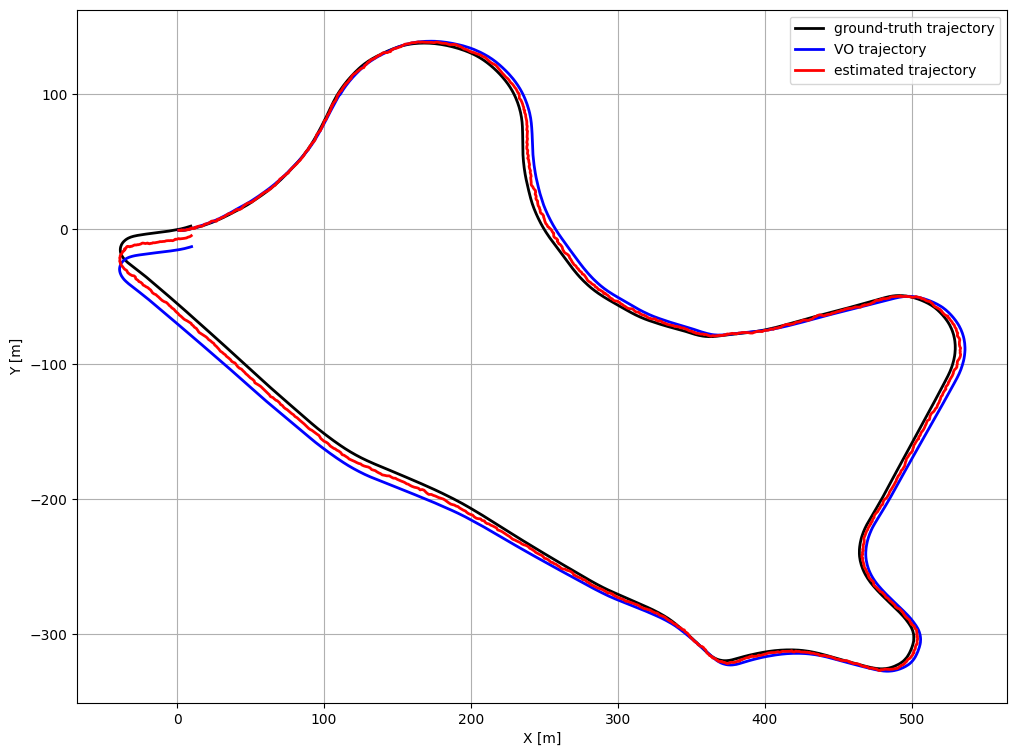

In [24]:
ckf3_0 = CubatureKalmanFilter(
    x=x_setup3.copy(), 
    P=P_setup3.copy(), 
    H=H_setup3.copy(),
    q=q3,
    r_vo=r_vo3,
    r_gps=r_gps3,
    setup=SetupEnum.SETUP_3,
)

error_ckf3_0 = ckf3_0.run(data=data, measurement_type=MeasurementDataEnum.ALL_DATA, debug_mode=True)

In [25]:
print(f"MAE: {error_ckf3_0[ErrorEnum.MAE]}")
print(f"RMSE: {error_ckf3_0[ErrorEnum.RMSE]}")
print(f"MAX: {error_ckf3_0[ErrorEnum.MAX]}")

mae_errors.append(error_ckf3_0[ErrorEnum.MAE])
rmse_errors.append(error_ckf3_0[ErrorEnum.RMSE])
max_errors.append(error_ckf3_0[ErrorEnum.MAX])

MAE: 1.819
RMSE: 2.566
MAX: 7.591


# Result

In [30]:
errors = np.concatenate([mae_errors, rmse_errors, max_errors], axis=0).reshape(3, 4)
errors

array([[ 3.82 ,  3.909,  1.536,  1.819],
       [ 5.449,  5.489,  2.074,  2.566],
       [15.244, 16.347,  6.567,  7.591]])

In [32]:
error_labels = ["VO MSE error", "CKF (input:IMU, mesurement:VO)", 
                "CKF (input:IMU, measurements:VO, GPS)", "CKF (input:INS, measurements:VO, INS)"]
indices = ["MAE", "RMSE", "MAX"]
pd.DataFrame(errors, columns=error_labels, index=indices)

,VO MSE error,"CKF (input:IMU, mesurement:VO)","CKF (input:IMU, measurements:VO, GPS)","CKF (input:INS, measurements:VO, INS)"
MAE,3.820,3.909,1.536,1.819
RMSE,5.449,5.489,2.074,2.566
MAX,15.244,16.347,6.567,7.591
